<a href="https://colab.research.google.com/github/mohammedqaidamanlift-hub/-NEUROCORTEX/blob/main/NeuroCortex_SRDF_Toy_Prototype_v2.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 **NeuroCortex SRDF Toy Prototype v2.0**

In [140]:
# ============================================================
# NeuroCortex SRDF Toy Prototype v2.0
# ============================================================

!pip -q install scikit-learn imbalanced-learn numpy pandas matplotlib seaborn

import json
import os
from copy import deepcopy
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from imblearn.over_sampling import SMOTE


SEED = 42

W_ACC = 0.50
W_SAFETY = 0.30
W_EFFICIENCY = 0.20

THETA = 0.85

RESOURCE_BUDGET = 3.0

K_MAX = 3

IMBALANCE_THRESHOLD = 3.0

np.random.seed(SEED)

print("=" * 70)
print("NeuroCortex SRDF Toy Prototype v2.0")
print("=" * 70)
print(f"Random seed         : {SEED}")
print(f"Arbiter threshold   : {THETA}")
print(f"Resource budget     : {RESOURCE_BUDGET}")
print(f"Rejection limit     : {K_MAX}")
print(f"Imbalance threshold : {IMBALANCE_THRESHOLD}")
print("=" * 70)

NeuroCortex SRDF Toy Prototype v2.0
Random seed         : 42
Arbiter threshold   : 0.85
Resource budget     : 3.0
Rejection limit     : 3
Imbalance threshold : 3.0


## 1. Synthetic Environment

In [141]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.80, 0.20],
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

print("\nDataset information")
print("-" * 70)
print("Total samples :", X.shape[0])
print("Features      :", X.shape[1])
print("Train samples :", X_train.shape[0])
print("Test samples  :", X_test.shape[0])
print("Class counts  :", np.bincount(y).tolist())


Dataset information
----------------------------------------------------------------------
Total samples : 1000
Features      : 10
Train samples : 700
Test samples  : 300
Class counts  : [796, 204]


## 2. Explicit Runtime State

In [142]:
BASELINE_GRAPH = [
    "Input",
    "RandomForest",
    "Output"
]

state = {
    "graph": BASELINE_GRAPH.copy(),
    "version": 0,
    "rejection_count": 0,
}

print("\nInitial execution graph")
print("-" * 70)
print(" -> ".join(state["graph"]))


Initial execution graph
----------------------------------------------------------------------
Input -> RandomForest -> Output


## 3. Context Acquisition

In [143]:
def acquire_context(y_train, current_state):

    counts = np.bincount(y_train)

    if len(counts) < 2:
        imbalance_ratio = float("inf")

    elif counts.min() == 0:
        imbalance_ratio = float("inf")

    else:
        imbalance_ratio = float(
            counts.max() / counts.min()
        )

    context = {
        "class_counts": counts.tolist(),
        "imbalance_ratio": imbalance_ratio,
        "graph": current_state["graph"].copy(),
        "state_version": int(current_state["version"]),
    }

    return context


context = acquire_context(
    y_train,
    state
)

print("\nContext Acquisition")
print("-" * 70)

print(
    json.dumps(
        context,
        indent=2
    )
)


Context Acquisition
----------------------------------------------------------------------
{
  "class_counts": [
    557,
    143
  ],
  "imbalance_ratio": 3.895104895104895,
  "graph": [
    "Input",
    "RandomForest",
    "Output"
  ],
  "state_version": 0
}


## 4. Trawler Analysis

In [144]:
def trawler_analysis(
    context,
    threshold=IMBALANCE_THRESHOLD
):

    ratio = context["imbalance_ratio"]

    detected = bool(
        np.isfinite(ratio)
        and ratio >= threshold
    )

    findings = {
        "class_imbalance": detected,
        "imbalance_ratio": float(ratio),
        "threshold": float(threshold),
        "trigger": (
            "class_imbalance"
            if detected
            else "no_trigger"
        ),
    }

    return findings


findings = trawler_analysis(
    context
)

print("\nTrawler Analysis")
print("-" * 70)

print(
    json.dumps(
        findings,
        indent=2
    )
)


Trawler Analysis
----------------------------------------------------------------------
{
  "class_imbalance": true,
  "imbalance_ratio": 3.895104895104895,
  "threshold": 3.0,
  "trigger": "class_imbalance"
}


## 5. Metric Function

In [145]:
def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred
            )
        ),

        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
    }

## 6. Baseline Model

In [146]:
baseline_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test
)

baseline_metrics = calculate_metrics(
    y_test,
    baseline_pred
)

print("\nBaseline RandomForest")
print("-" * 70)

for name, value in baseline_metrics.items():
    print(
        f"{name:>10}: {value:.6f}"
    )


Baseline RandomForest
----------------------------------------------------------------------
  accuracy: 0.956667
 precision: 0.913793
    recall: 0.868852
        f1: 0.890756


## 7. Structural Candidate Generator

In [147]:
def generate_candidates(
    findings
):

    if not findings["class_imbalance"]:
        return []

    candidates = [

        {
            "name":
                "GradientBoosting",

            "graph":
                [
                    "Input",
                    "GradientBoosting",
                    "Output"
                ],

            "resource_cost":
                1.5,

            "description":
                "Replace the baseline classifier."
        },

        {
            "name":
                "SMOTE_RandomForest",

            "graph":
                [
                    "Input",
                    "SMOTE",
                    "RandomForest",
                    "Output"
                ],

            "resource_cost":
                2.0,

            "description":
                "Insert SMOTE before RandomForest."
        },
    ]

    return candidates


candidates = generate_candidates(
    findings
)

print("\nStructural Candidate Generation")
print("-" * 70)

print(
    "Number of candidates:",
    len(candidates)
)

for candidate in candidates:

    print(
        f"\nCandidate: {candidate['name']}"
    )

    print(
        "Graph:",
        " -> ".join(
            candidate["graph"]
        )
    )

    print(
        "Resource cost:",
        candidate["resource_cost"]
    )

    print(
        "Description:",
        candidate["description"]
    )


Structural Candidate Generation
----------------------------------------------------------------------
Number of candidates: 2

Candidate: GradientBoosting
Graph: Input -> GradientBoosting -> Output
Resource cost: 1.5
Description: Replace the baseline classifier.

Candidate: SMOTE_RandomForest
Graph: Input -> SMOTE -> RandomForest -> Output
Resource cost: 2.0
Description: Insert SMOTE before RandomForest.


## 8. Candidate Evaluation

In [148]:
def evaluate_candidate(
    candidate
):

    test_fingerprint_before = (
        float(np.sum(X_test)),
        float(np.mean(X_test)),
        int(len(y_test)),
    )

    if candidate["name"] == "GradientBoosting":

        model = GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            random_state=SEED,
        )

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

    elif candidate["name"] == "SMOTE_RandomForest":

        smote = SMOTE(
            random_state=SEED
        )

        X_resampled, y_resampled = (
            smote.fit_resample(
                X_train,
                y_train
            )
        )

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
        )

        model.fit(
            X_resampled,
            y_resampled
        )

        predictions = model.predict(
            X_test
        )

    else:

        raise ValueError(
            f"Unknown candidate: "
            f"{candidate['name']}"
        )

    metrics = calculate_metrics(
        y_test,
        predictions
    )

    test_fingerprint_after = (
        float(np.sum(X_test)),
        float(np.mean(X_test)),
        int(len(y_test)),
    )

    safety_checks = {

        "finite_predictions":
            bool(
                np.all(
                    np.isfinite(
                        predictions
                    )
                )
            ),

        "finite_metrics":
            bool(
                all(
                    np.isfinite(
                        list(
                            metrics.values()
                        )
                    )
                )
            ),

        "test_set_unchanged":
            bool(
                test_fingerprint_before
                ==
                test_fingerprint_after
            ),
    }

    safety_pass = bool(
        all(
            safety_checks.values()
        )
    )

    efficiency = float(
        min(
            1.0,
            RESOURCE_BUDGET
            /
            candidate["resource_cost"]
        )
    )

    utility = float(
        W_ACC * metrics["accuracy"]
        +
        W_SAFETY * float(safety_pass)
        +
        W_EFFICIENCY * efficiency
    )

    result = deepcopy(
        candidate
    )

    result.update({

        "metrics":
            metrics,

        "safety_checks":
            safety_checks,

        "safety_pass":
            safety_pass,

        "efficiency":
            efficiency,

        "utility":
            utility,

        "predictions":
            predictions,
    })

    return result


evaluated_candidates = []

for candidate in candidates:

    result = evaluate_candidate(
        candidate
    )

    evaluated_candidates.append(
        result
    )


print("\nCandidate Evaluation")
print("-" * 70)

for result in evaluated_candidates:

    print(
        f"\n{result['name']}"
    )

    print(
        "Accuracy:",
        f"{result['metrics']['accuracy']:.6f}"
    )

    print(
        "Precision:",
        f"{result['metrics']['precision']:.6f}"
    )

    print(
        "Recall:",
        f"{result['metrics']['recall']:.6f}"
    )

    print(
        "F1:",
        f"{result['metrics']['f1']:.6f}"
    )

    print(
        "Safety:",
        result["safety_pass"]
    )

    print(
        "Efficiency:",
        f"{result['efficiency']:.6f}"
    )

    print(
        "Utility:",
        f"{result['utility']:.6f}"
    )


Candidate Evaluation
----------------------------------------------------------------------

GradientBoosting
Accuracy: 0.963333
Precision: 0.946429
Recall: 0.868852
F1: 0.905983
Safety: True
Efficiency: 1.000000
Utility: 0.981667

SMOTE_RandomForest
Accuracy: 0.956667
Precision: 0.900000
Recall: 0.885246
F1: 0.892562
Safety: True
Efficiency: 1.000000
Utility: 0.978333


## 9. Structural Invariants

In [149]:
ALLOWED_NODES = {

    "Input",
    "Output",
    "RandomForest",
    "GradientBoosting",
    "SMOTE",
}


def invariant_check(
    candidate_graph
):

    graph = list(
        candidate_graph
    )

    checks = {

        "starts_with_input":
            (
                len(graph) >= 2
                and graph[0] == "Input"
            ),

        "ends_with_output":
            (
                len(graph) >= 2
                and graph[-1] == "Output"
            ),

        "unique_nodes":
            (
                len(graph)
                ==
                len(set(graph))
            ),

        "allowed_nodes":
            (
                set(graph)
                .issubset(
                    ALLOWED_NODES
                )
            ),
    }

    checks["all_pass"] = bool(
        all(
            checks.values()
        )
    )

    return checks


print("\nStructural Invariant Checks")
print("-" * 70)

for candidate in evaluated_candidates:

    result = invariant_check(
        candidate["graph"]
    )

    print(
        candidate["name"],
        "=>",
        result
    )


Structural Invariant Checks
----------------------------------------------------------------------
GradientBoosting => {'starts_with_input': True, 'ends_with_output': True, 'unique_nodes': True, 'allowed_nodes': True, 'all_pass': True}
SMOTE_RandomForest => {'starts_with_input': True, 'ends_with_output': True, 'unique_nodes': True, 'allowed_nodes': True, 'all_pass': True}


## 10. Hybrid Arbiter

In [150]:
def authorize_candidate(
    candidate,
    current_graph
):

    invariant = invariant_check(
        candidate["graph"]
    )

    invariant_pass = bool(
        invariant["all_pass"]
    )

    resource_pass = bool(
        candidate["resource_cost"]
        <=
        RESOURCE_BUDGET
    )

    safety_pass = bool(
        candidate["safety_pass"]
    )

    utility_pass = bool(
        candidate["utility"]
        >=
        THETA
    )

    accepted = bool(

        invariant_pass
        and
        resource_pass
        and
        safety_pass
        and
        utility_pass
    )

    return {

        "accepted":
            accepted,

        "invariant":
            invariant,

        "invariant_pass":
            invariant_pass,

        "resource_pass":
            resource_pass,

        "safety_pass":
            safety_pass,

        "utility_pass":
            utility_pass,

        "current_graph":
            list(current_graph),

        "candidate_graph":
            list(candidate["graph"]),
    }


for candidate in evaluated_candidates:

    candidate["authorization"] = (
        authorize_candidate(
            candidate,
            state["graph"]
        )
    )


print("\nHybrid Arbiter Decisions")
print("-" * 70)

for candidate in evaluated_candidates:

    auth = candidate[
        "authorization"
    ]

    status = (
        "ACCEPT"
        if auth["accepted"]
        else
        "REJECT"
    )

    print(
        f"{candidate['name']}: {status}"
    )

    print(
        "  Utility:",
        f"{candidate['utility']:.6f}"
    )

    print(
        "  Invariants:",
        auth["invariant_pass"]
    )

    print(
        "  Resource:",
        auth["resource_pass"]
    )

    print(
        "  Safety:",
        auth["safety_pass"]
    )

    print(
        "  Threshold:",
        auth["utility_pass"]
    )


Hybrid Arbiter Decisions
----------------------------------------------------------------------
GradientBoosting: ACCEPT
  Utility: 0.981667
  Invariants: True
  Resource: True
  Safety: True
  Threshold: True
SMOTE_RandomForest: ACCEPT
  Utility: 0.978333
  Invariants: True
  Resource: True
  Safety: True
  Threshold: True


## 11. Select Authorized Candidate

In [151]:
authorized_candidates = [

    candidate

    for candidate
    in evaluated_candidates

    if candidate[
        "authorization"
    ]["accepted"]
]


if authorized_candidates:

    selected = max(

        authorized_candidates,

        key=lambda candidate:
            candidate["utility"]
    )

else:

    selected = None


print("\nAuthorized Candidate Selection")
print("-" * 70)

if selected is None:

    print(
        "No candidate passed all "
        "authorization conditions."
    )

else:

    for candidate in authorized_candidates:

        print(
            f"{candidate['name']}: "
            f"utility="
            f"{candidate['utility']:.6f}"
        )

    print(
        "\nSelected candidate:",
        selected["name"]
    )


Authorized Candidate Selection
----------------------------------------------------------------------
GradientBoosting: utility=0.981667
SMOTE_RandomForest: utility=0.978333

Selected candidate: GradientBoosting


## 12. Commit or Reject

In [152]:
decision_log = []

backoff_triggered = False


if selected is not None:

    old_graph = (
        state["graph"].copy()
    )

    state["graph"] = (
        selected["graph"].copy()
    )

    state["version"] += 1

    state["rejection_count"] = 0

    decision_log.append({

        "decision":
            "ACCEPT",

        "candidate":
            selected["name"],

        "old_graph":
            old_graph,

        "new_graph":
            state["graph"].copy(),

        "state_version":
            state["version"],
    })

    print(
        "\nStructural mutation committed."
    )

    print(
        "Old graph:",
        " -> ".join(old_graph)
    )

    print(
        "New graph:",
        " -> ".join(state["graph"])
    )

else:

    for candidate in evaluated_candidates:

        decision_log.append({

            "decision":
                "REJECT",

            "candidate":
                candidate["name"],

            "authorization":
                candidate["authorization"],
        })

    state["rejection_count"] += 1

    if (
        state["rejection_count"]
        >=
        K_MAX
    ):

        backoff_triggered = True

        state["rejection_count"] = 0

    decision_log.append({

        "decision":
            "REJECT_ALL",

        "graph_preserved":
            True,

        "backoff_triggered":
            backoff_triggered,

        "rejection_count":
            state["rejection_count"],
    })

    print(
        "\nAll candidates rejected."
    )

    print(
        "Current graph:",
        " -> ".join(state["graph"])
    )

    print(
        "Backoff triggered:",
        backoff_triggered
    )


print(
    "\nRuntime state version:",
    state["version"]
)

print(
    "Rejection counter:",
    state["rejection_count"]
)


Structural mutation committed.
Old graph: Input -> RandomForest -> Output
New graph: Input -> GradientBoosting -> Output

Runtime state version: 1
Rejection counter: 0


## 13. Observed Outcome

In [153]:
if selected is not None:

    final_metrics = (
        selected["metrics"]
    )

else:

    final_metrics = (
        baseline_metrics
    )


final_accuracy = float(
    final_metrics["accuracy"]
)


absolute_accuracy_change = float(

    final_accuracy
    -
    baseline_metrics["accuracy"]
)


relative_accuracy_change_percent = float(

    (
        absolute_accuracy_change
        /
        baseline_metrics["accuracy"]
    )
    *
    100.0
)


outcome = {

    "baseline_graph":
        BASELINE_GRAPH,

    "final_graph":
        state["graph"],

    "selected_solution":
        (
            selected["name"]
            if selected is not None
            else None
        ),

    "baseline_metrics":
        baseline_metrics,

    "final_metrics":
        final_metrics,

    "absolute_accuracy_change":
        absolute_accuracy_change,

    "relative_accuracy_change_percent":
        relative_accuracy_change_percent,
}


print("\nObserved Prototype Outcome")
print("-" * 70)

print(
    json.dumps(
        outcome,
        indent=2
    )
)


Observed Prototype Outcome
----------------------------------------------------------------------
{
  "baseline_graph": [
    "Input",
    "RandomForest",
    "Output"
  ],
  "final_graph": [
    "Input",
    "GradientBoosting",
    "Output"
  ],
  "selected_solution": "GradientBoosting",
  "baseline_metrics": {
    "accuracy": 0.9566666666666667,
    "precision": 0.9137931034482759,
    "recall": 0.8688524590163934,
    "f1": 0.8907563025210085
  },
  "final_metrics": {
    "accuracy": 0.9633333333333334,
    "precision": 0.9464285714285714,
    "recall": 0.8688524590163934,
    "f1": 0.905982905982906
  },
  "absolute_accuracy_change": 0.00666666666666671,
  "relative_accuracy_change_percent": 0.6968641114982623
}


## 14. Comparison Table

In [154]:
rows = []

rows.append({

    "configuration":
        "Baseline RandomForest",

    "accuracy":
        baseline_metrics["accuracy"],

    "precision":
        baseline_metrics["precision"],

    "recall":
        baseline_metrics["recall"],

    "f1":
        baseline_metrics["f1"],

    "resource_cost":
        0.0,

    "utility":
        np.nan,

    "authorized":
        False,
})


for candidate in evaluated_candidates:

    rows.append({

        "configuration":
            candidate["name"],

        "accuracy":
            candidate["metrics"]["accuracy"],

        "precision":
            candidate["metrics"]["precision"],

        "recall":
            candidate["metrics"]["recall"],

        "f1":
            candidate["metrics"]["f1"],

        "resource_cost":
            candidate["resource_cost"],

        "utility":
            candidate["utility"],

        "authorized":
            candidate[
                "authorization"
            ]["accepted"],
    })


comparison_df = pd.DataFrame(
    rows
)

print("\nCandidate Comparison")
print("-" * 70)

display(
    comparison_df
)


Candidate Comparison
----------------------------------------------------------------------


,configuration,accuracy,precision,recall,f1,resource_cost,utility,authorized
0,Baseline RandomForest,0.956667,0.913793,0.868852,0.890756,0.0,NaN,False
1,GradientBoosting,0.963333,0.946429,0.868852,0.905983,1.5,0.981667,True
2,SMOTE_RandomForest,0.956667,0.900000,0.885246,0.892562,2.0,0.978333,True


## 15. Accuracy Visualization

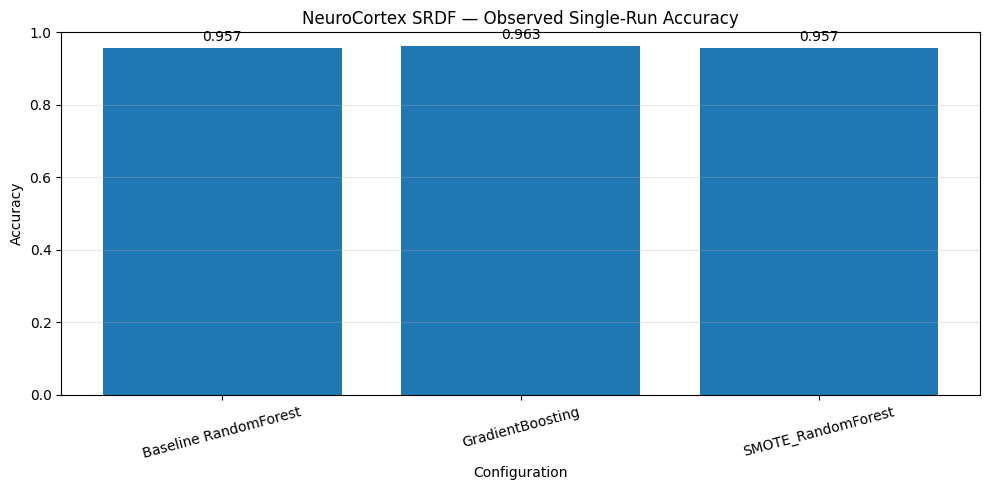

In [155]:
plt.figure(
    figsize=(10, 5)
)

bars = plt.bar(
    comparison_df["configuration"],
    comparison_df["accuracy"]
)

plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Configuration"
)

plt.title(
    "NeuroCortex SRDF — "
    "Observed Single-Run Accuracy"
)

plt.ylim(
    0,
    1
)

for bar, value in zip(
    bars,
    comparison_df["accuracy"]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width()
        /
        2,

        value + 0.01,

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

## 16. Confusion Matrix

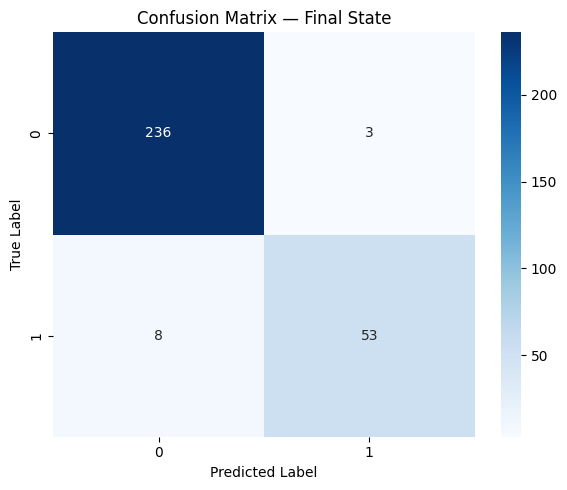

In [156]:
if selected is not None:

    final_predictions = (
        selected["predictions"]
    )

else:

    final_predictions = (
        baseline_pred
    )


cm = confusion_matrix(
    y_test,
    final_predictions
)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — Final State"
)

plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()

plt.show()

## 17. Execution Graph Transition Report

In [157]:
print("\nExecution Graph Transition")
print("=" * 70)

print(
    "G_t   =",
    " -> ".join(BASELINE_GRAPH)
)

print(
    "G_t+1 =",
    " -> ".join(state["graph"])
)


if selected is not None:

    print(
        "\nStructural adaptation: YES"
    )

    print(
        "Mutation:",
        selected["name"]
    )

else:

    print(
        "\nStructural adaptation: NO"
    )


Execution Graph Transition
G_t   = Input -> RandomForest -> Output
G_t+1 = Input -> GradientBoosting -> Output

Structural adaptation: YES
Mutation: GradientBoosting


## 18. JSON Serialization

In [158]:
def make_json_safe(value):

    if isinstance(
        value,
        np.generic
    ):

        return value.item()

    if isinstance(
        value,
        np.ndarray
    ):

        return value.tolist()

    if isinstance(
        value,
        dict
    ):

        return {
            str(key):
                make_json_safe(val)

            for key, val
            in value.items()
        }

    if isinstance(
        value,
        list
    ):

        return [
            make_json_safe(item)
            for item in value
        ]

    return value

## 19. Complete Experiment Record

In [159]:
candidate_records = []


for candidate in evaluated_candidates:

    record = {

        "name":
            candidate["name"],

        "graph":
            candidate["graph"],

        "resource_cost":
            candidate["resource_cost"],

        "description":
            candidate["description"],

        "metrics":
            candidate["metrics"],

        "safety_checks":
            candidate["safety_checks"],

        "safety_pass":
            candidate["safety_pass"],

        "efficiency":
            candidate["efficiency"],

        "utility":
            candidate["utility"],

        "authorization":
            candidate["authorization"],
    }

    candidate_records.append(
        make_json_safe(record)
    )


result_record = {

    "prototype":
        "NeuroCortex SRDF Toy Prototype",

    "version":
        "2.0.0",

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "random_seed":
        SEED,

    "configuration": {

        "theta":
            THETA,

        "weights": {

            "accuracy":
                W_ACC,

            "safety":
                W_SAFETY,

            "efficiency":
                W_EFFICIENCY,
        },

        "resource_budget":
            RESOURCE_BUDGET,

        "k_max":
            K_MAX,

        "imbalance_threshold":
            IMBALANCE_THRESHOLD,
    },

    "dataset": {

        "n_samples":
            int(X.shape[0]),

        "n_features":
            int(X.shape[1]),

        "train_samples":
            int(X_train.shape[0]),

        "test_samples":
            int(X_test.shape[0]),

        "class_counts":
            np.bincount(y).tolist(),
    },

    "context":
        make_json_safe(context),

    "trawler_findings":
        make_json_safe(findings),

    "baseline": {

        "graph":
            BASELINE_GRAPH,

        "metrics":
            make_json_safe(
                baseline_metrics
            ),
    },

    "candidates":
        candidate_records,

    "selected_solution":
        (
            selected["name"]
            if selected is not None
            else None
        ),

    "final_graph":
        state["graph"],

    "state_version":
        state["version"],

    "observed_outcome":
        make_json_safe(outcome),

    "decision_log":
        make_json_safe(decision_log),

    "interpretation":
        (
            "Single-run feasibility demonstration "
            "of controlled runtime structural adaptation. "
            "The result is not a statistical benchmark and "
            "does not establish general performance superiority "
            "or general AI safety."
        ),
}

## 20. Save Results

In [160]:
RESULT_PATH = (
    "srdf_v2_results.json"
)


with open(
    RESULT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        result_record,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "\nResult file saved:"
)

print(
    os.path.abspath(
        RESULT_PATH
    )
)

print(
    "File size:",
    os.path.getsize(
        RESULT_PATH
    ),
    "bytes"
)


Result file saved:
/content/srdf_v2_results.json
File size: 4994 bytes


## 21. Final Automated Audit

In [161]:
audit = {

    "context_acquisition":
        isinstance(
            context,
            dict
        ),

    "trawler_executed":
        isinstance(
            findings,
            dict
        ),

    "candidate_generation":
        isinstance(
            candidates,
            list
        ),

    "candidate_evaluation":
        len(
            evaluated_candidates
        )
        ==
        len(
            candidates
        ),

    "invariants_present":
        all(
            "authorization"
            in candidate
            for candidate
            in evaluated_candidates
        ),

    "resource_check_present":
        all(
            "resource_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "safety_check_present":
        all(
            "safety_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "utility_threshold_present":
        all(
            "utility_pass"
            in candidate["authorization"]
            for candidate
            in evaluated_candidates
        ),

    "state_version_present":
        "version" in state,

    "result_file_exists":
        os.path.exists(
            RESULT_PATH
        ),
}


audit_pass = all(
    audit.values()
)


print("\nFinal Prototype Audit")
print("=" * 70)

for name, value in audit.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if value else 'FAIL'}"
    )

print("=" * 70)

print(
    "OVERALL:",
    "PASS"
    if audit_pass
    else
    "FAIL"
)


Final Prototype Audit
context_acquisition                : PASS
trawler_executed                   : PASS
candidate_generation               : PASS
candidate_evaluation               : PASS
invariants_present                 : PASS
resource_check_present             : PASS
safety_check_present               : PASS
utility_threshold_present          : PASS
state_version_present              : PASS
result_file_exists                 : PASS
OVERALL: PASS


## 22. Scientific Interpretation

In [162]:
print("""
======================================================================
SCIENTIFIC INTERPRETATION
======================================================================

This execution demonstrates an executable proposal-evaluation-
authorization-commit workflow for bounded runtime structural adaptation.

The experiment does NOT establish:

1. General self-evolving artificial intelligence.
2. Unrestricted structural or program synthesis.
3. Universal or formal real-world AI safety.
4. Statistical significance.
5. General performance superiority.
6. Superiority over existing adaptive-agent architectures.
7. Generalization beyond this experimental setting.

The observed numerical results belong to this executed run only.

Any manuscript claim involving numerical results must be generated
from the saved srdf_v2_results.json file after actual execution.

======================================================================
""")


SCIENTIFIC INTERPRETATION

This execution demonstrates an executable proposal-evaluation-
authorization-commit workflow for bounded runtime structural adaptation.

The experiment does NOT establish:

1. General self-evolving artificial intelligence.
2. Unrestricted structural or program synthesis.
3. Universal or formal real-world AI safety.
4. Statistical significance.
5. General performance superiority.
6. Superiority over existing adaptive-agent architectures.
7. Generalization beyond this experimental setting.

The observed numerical results belong to this executed run only.

Any manuscript claim involving numerical results must be generated
from the saved srdf_v2_results.json file after actual execution.


